In [72]:
print("Welcome to Today's Practice")

for i in "July":
    
    print(i)

Welcome to Today's Practice
J
u
l
y


In [73]:
import numpy as np 



# A 5 X5 image all gray (value 0.5 = medium gray)



img = np.full((5, 5), fill_value=0.5)


print(img)

[[0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]]


In [74]:


img[1:4, 1:4] = [1.0]


print(img)

[[0.5 0.5 0.5 0.5 0.5]
 [0.5 1.  1.  1.  0.5]
 [0.5 1.  1.  1.  0.5]
 [0.5 1.  1.  1.  0.5]
 [0.5 0.5 0.5 0.5 0.5]]


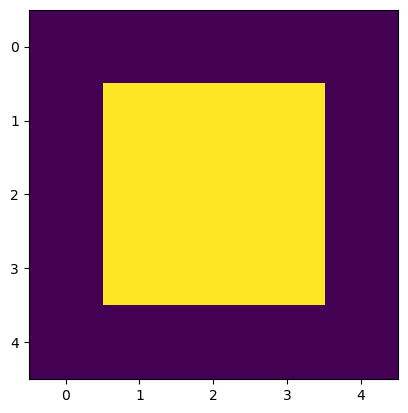

In [75]:
import matplotlib.pyplot as plt 


plt.imshow(img)

In [76]:
### FuLL IMAGE GENERATION + SAVING FOLDERS

In [77]:
import os 



os.makedirs("skin_data/train/positive", exist_ok=True)
os.makedirs("skin_data/train/negative", exist_ok=True)
os.makedirs("skin_data/test/positive", exist_ok=True)
os.makedirs("skin_data/test/negative", exist_ok=True)


print("Folders Created!")

Folders Created!


### Let us Understand Image generation function, line by line




In [78]:
import numpy as np 


def make_skin_image(has_nodule=True, size=32):
    
    #So let us create the main image first 
    
    img = np.random.normal(0.4, 0.05, (size, size))
    
    
    if has_nodule == True:
        
        #Pick a random center for the nodule patch
        
        #np.random.randint(low,high) gives a random whole number between low and high-1
        # we pick betwen 8 and24 (not too close to the edge, so the patch fits
        
        cx = np.random.randint(8, 24) #random row position for the center
        cy = np.random.randint(8, 24)  #Random column position for center
        
        
        
        #How big is the patch? Random size between 3 and 6 pixels wide
        
        patch_size = np.random.randint(3, 7)
        
        #Now make that patch bright (nodule = brighter than surrounding skin)
        
        #img[cx -patch_size : cx + patch_size, cy - patch_size : cy + patch_size]
        
        #means: "all rows from (cx - patch_size) to (cx + patch_size)"
        # "AND all columns from (cy - patch_size) to (cy + patch_size)"
        

        #This is a SQUARE region centered at (cx, cy)
        # We set it to a bright value (around 0.85) to make it stand out
        
        brightness = np.random.uniform(0.75, 0.95)
        
        img[cx - patch_size : cx + patch_size, cy - patch_size : cy + patch_size] = brightness
        
# ----- LINE 3 -------

#np.clip(img, 0, 1) - safety net

# After adding brightness, some pixels might go above 1.0 or below 0.0

#Clip forces All values to stay between 0 (black) and (white)
        
        
    img = np.clip(img, 0, 1)
    
    
    
# ----- LINE 4 -----
# Convert to float32 - PyTorch and most image libraries prefer float32 over float64
# float32 uses less memory and runs faster on GPU
    
    return img.astype(np.float32)


    

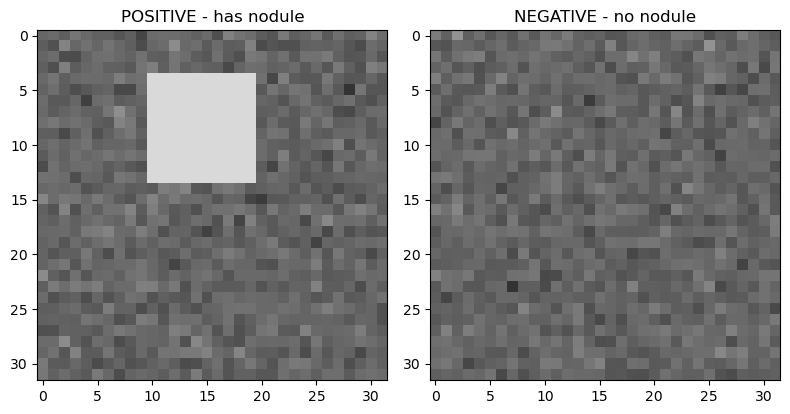

In [79]:
from matplotlib import pyplot as plt 


pos_img = make_skin_image(has_nodule=True)
neg_img = make_skin_image(has_nodule=False)



#Plot them side by side


fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(pos_img, cmap="gray", vmin=0, vmax=1)

axes[0].set_title("POSITIVE - has nodule")

axes[1].imshow(neg_img, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("NEGATIVE - no nodule")

plt.tight_layout()
plt.show()


In [ ]:
## Saving the Images to Folders using the PIL

#PIL (PiLLOW) is a Python library for saving/loading 
# image files (PNG, JPG etc). we need it because
#np.save saves .npy files that only python understands but PNG/JPG files any software can open


In [ ]:
from PIL import Image



def save_image(img_array, filepath):
    
    
    # Img_array is our (32, 32) float32 numpy array with values 0.0 to 1.0
    # PIL wants values 0 to 255 (uint8), so we multiply by 255 and convert
    
    img_uint8 = (img_array * 255).astype(np.uint8)
    
    # (img_array * 255) => turns 0.0=>0, 0.5 => 127 , 1.0=>255
    # .astype(np.uint8) => converts to integer type (uint8 = unsigned 8-bit = 0 to 255)
    
    pil_img = Image.fromarray(img_uint8, model="L")
    #mode="L" => "L" stands for Luminance = grayscale (1 channel)

In [92]:
from PIL import  Image



np.random.seed(5)

image = np.random.normal(loc=0.4, scale=0.03, size=(34, 23, 3))



image = image.astype(np.float32)

In [101]:
image_to_uint = (image * 255).astype(np.uint8)


new_image = Image.fromarray(image_to_uint, mode="RGB")



In [103]:
os.makedirs("images/Cats", exist_ok=True)

In [114]:
new_image.save(os.path.join("images/Cats/cats.png"))
